**Initialisation, Imports et Alignement des Données**

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Alignement du chemin racine
if '..' not in sys.path:
    sys.path.append('..')

# On réutilise les structures du notebook précédent pour garantir le bon formatage
from src.preprocessing import build_preprocessing_pipeline, create_clinical_features

# 1. Rechargement des données et application exacte du split stratifié
df_raw = pd.read_csv("../data/raw/alzheimer_clinical.csv")
df = create_clinical_features(df_raw)

target_map = {'CN': 0, 'MCI': 1, 'AD': 2}
y = df['Label'].map(target_map).values
X = df.drop(columns=['Label', 'Subject_ID'], errors='ignore')

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Récupération des hyperparamètres optimaux trouvés par ton étude Optuna
# On réentraîne le pipeline final pour l'avoir en mémoire active dans ce notebook
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline

NUMERICAL_FEATURES_CLEAN = [
    'Age', 'Education', 'MMSE', 'nWBV', 'eTIV', 'ASF',
    'Abeta42', 'pTau181', 'NfL', 'FAQ', 'APOE4',
    'Amyloid_Tau_Ratio', 'Cog_Functional_Score', 'Brain_Age_Ratio',
    'APOE4_Risk', 'Comorbidity_Index', 'NfL_Age_Adjusted'
]
CATEGORICAL_FEATURES_CLEAN = ['Sex', 'Hypertension', 'Diabetes', 'Depression_Hx']
feature_names = NUMERICAL_FEATURES_CLEAN + CATEGORICAL_FEATURES_CLEAN

# Remplacement automatique par les hyperparamètres optimaux trouvés par ton Optuna
best_params = {
    'clf__n_estimators': 462,
    'clf__max_depth': 5,
    'clf__learning_rate': 0.017074,
    'clf__num_leaves': 37,
    'clf__min_child_samples': 36,
    'clf__subsample': 0.9583,
    'clf__colsample_bytree': 0.6575,
    'clf__reg_alpha': 0.0240,
    'clf__reg_lambda': 4.118e-05
}

champion_pipeline = Pipeline([
    ('preprocessor', build_preprocessing_pipeline(NUMERICAL_FEATURES_CLEAN, CATEGORICAL_FEATURES_CLEAN)),
    ('clf', LGBMClassifier(objective='multiclass', num_class=3, class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1))
])
champion_pipeline.set_params(**best_params)
champion_pipeline.fit(X_train, y_train)

# Sauvegarde des prédictions pour le ciblage des patients
y_pred = champion_pipeline.predict(X_test)

print("Modèle optimal réentraîné et disponible pour l'extraction XAI !")

Modèle optimal réentraîné et disponible pour l'extraction XAI !


**Calcul de l'Explainer SHAP (TreeExplainer)**

In [2]:
import shap

# Extraction des composants
preprocessor_fitted = champion_pipeline.named_steps['preprocessor']
lgbm_model = champion_pipeline.named_steps['clf']

# Transformation matricielle des données de test
X_test_transformed = preprocessor_fitted.transform(X_test)

# Calcul instantané via TreeExplainer (optimisé pour LightGBM)
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test_transformed)

print(f" Dimensions de la matrice SHAP : {np.array(shap_values).shape}")

 Dimensions de la matrice SHAP : (300, 21, 3)


**Graphiques Globaux (Beeswarm & Importance)**

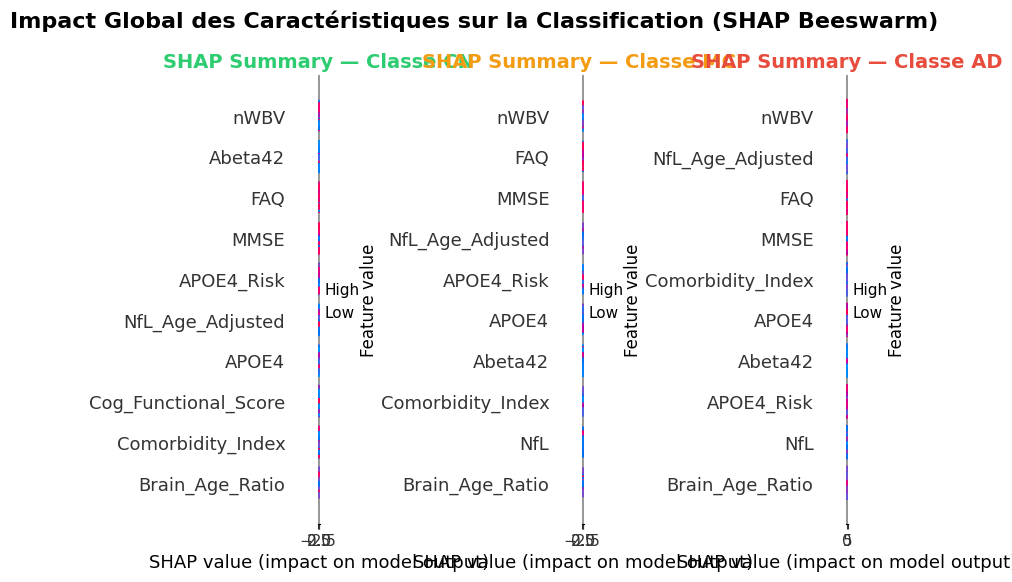

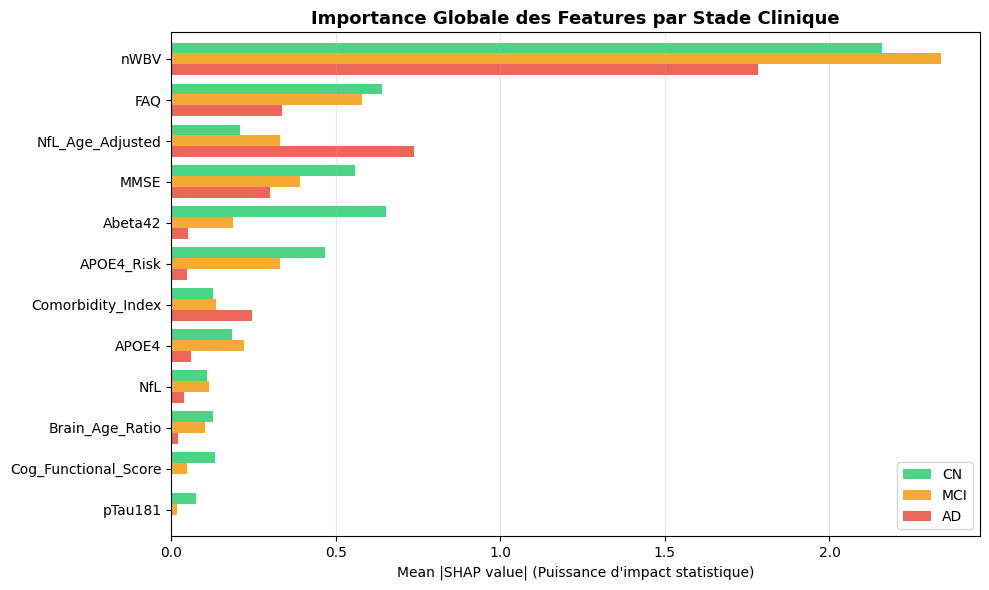

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

os.makedirs("../reports/figures", exist_ok=True)
class_names = ['CN', 'MCI', 'AD']
class_colors = ['#2ECC71', '#F39C12', '#E74C3C']


fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for idx, (cls_name, cls_color) in enumerate(zip(class_names, class_colors)):
    plt.sca(axes[idx])
    
    # Extraction propre des valeurs SHAP pour la classe en cours (Forme attendue : 300, 21)
    shap_values_for_class = shap_values[:, :, idx]
    
    shap.summary_plot(
        shap_values_for_class, 
        X_test_transformed,
        feature_names=feature_names, 
        plot_type='dot',
        max_display=10, 
        show=False, 
        color_bar=True
    )
    axes[idx].set_title(f"SHAP Summary — Classe {cls_name}", fontsize=14, fontweight='bold', color=cls_color)

plt.suptitle("Impact Global des Caractéristiques sur la Classification (SHAP Beeswarm)", fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig("../reports/figures/05_shap_beeswarm.png", dpi=200, bbox_inches='tight')
plt.show()

# ── 2. Génération du Bar Plot global basé sur l'importance moyenne absolue ──
shap_importance = pd.DataFrame({
    cls: np.abs(shap_values[:, :, i]).mean(axis=0) for i, cls in enumerate(class_names)
}, index=feature_names)

shap_importance['Mean'] = shap_importance.mean(axis=1)
shap_importance = shap_importance.sort_values('Mean', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 6))
shap_importance[class_names].plot(kind='barh', ax=ax, color=class_colors, alpha=0.85, width=0.8)
ax.set_xlabel("Mean |SHAP value| (Puissance d'impact statistique)")
ax.set_title("Importance Globale des Features par Stade Clinique", fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/06_shap_importance.png", dpi=200, bbox_inches='tight')
plt.show()



**Graphiques de Dépendance Clinique (Interactions Multi-Features)**

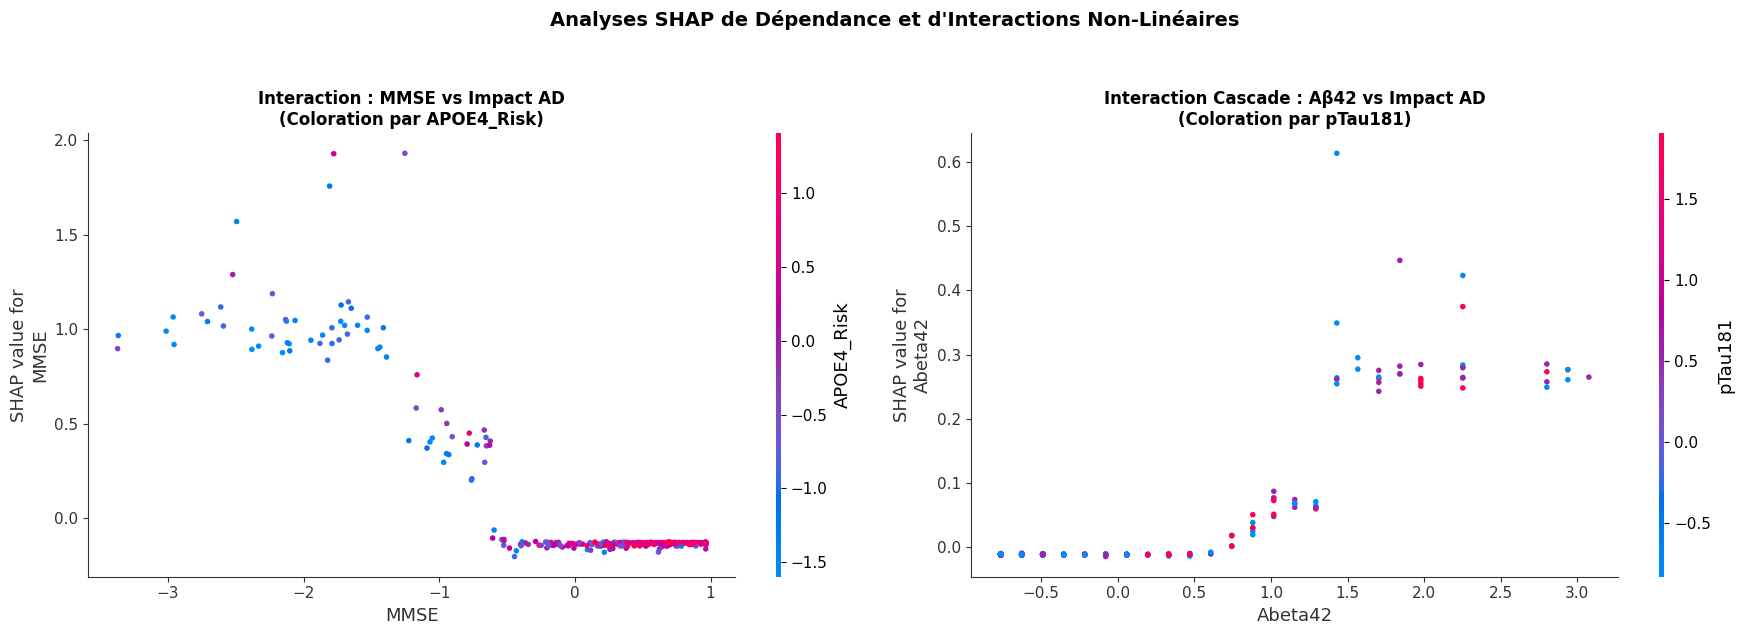

In [7]:
import os
import matplotlib.pyplot as plt
import shap

os.makedirs("../reports/figures", exist_ok=True)

# Récupération des index des colonnes dans la matrice transformée
mmse_idx = feature_names.index('MMSE')
apoe4_idx = feature_names.index('APOE4_Risk')
abeta_idx = feature_names.index('Abeta42')
ptau_idx = feature_names.index('pTau181')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Graphique A : Interaction Cognition × Risque Génétique pour le stade AD
plt.sca(axes[0])
shap.dependence_plot(
    mmse_idx, 
    shap_values[:, :, 2], # Index 2 = Classe AD
    X_test_transformed,
    feature_names=feature_names, 
    interaction_index=apoe4_idx,
    ax=axes[0], 
    show=False
)
axes[0].set_title("Interaction : MMSE vs Impact AD\n(Coloration par APOE4_Risk)", fontweight='bold', fontsize=12)

# Graphique B : Interaction Moléculaire (Cascade Amyloïde/Tau) pour le stade AD
plt.sca(axes[1])
shap.dependence_plot(
    abeta_idx, 
    shap_values[:, :, 2], 
    X_test_transformed,
    feature_names=feature_names, 
    interaction_index=ptau_idx,
    ax=axes[1], 
    show=False
)
axes[1].set_title("Interaction Cascade : Aβ42 vs Impact AD\n(Coloration par pTau181)", fontweight='bold', fontsize=12)

plt.suptitle("Analyses SHAP de Dépendance et d'Interactions Non-Linéaires", fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig("../reports/figures/07_shap_dependence.png", dpi=200, bbox_inches='tight')
plt.show()



**Focus Local et Confrontation (SHAP Waterfall vs LIME)**

🩺 PROFIL CLINIQUE DU PATIENT DE TEST CIBLÉ (Index 3) :
Age            72.160641
MMSE           22.630252
nWBV            0.676992
Abeta42       330.367829
pTau181        72.048372
FAQ                 19.0
APOE4_Risk           3.0
Name: 870, dtype: object


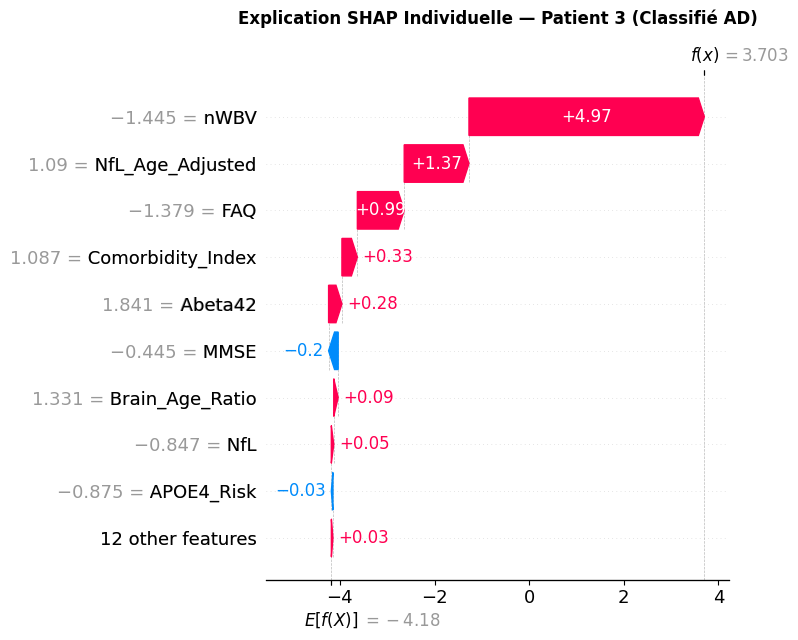

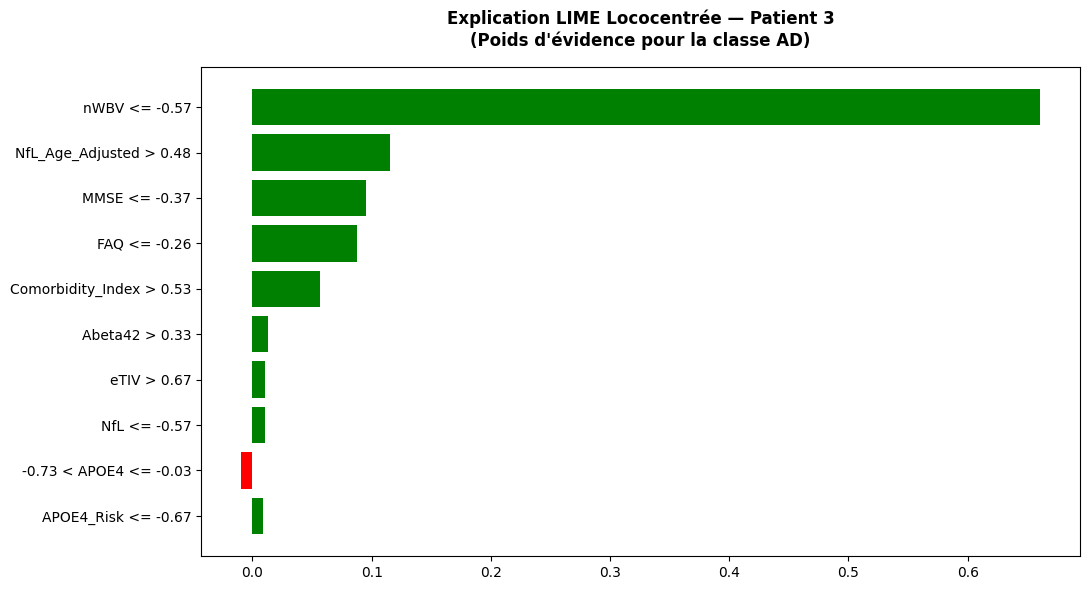

💾 [SUCCESS] Les Figures 08 (SHAP) et 09 (LIME) sont sauvegardées sans conflit de dimensions !


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import shap
import lime
import lime.lime_tabular

# 1. Ciblage du premier vrai positif Alzheimer (AD)
ad_indices = np.where((y_test == 2) & (y_pred == 2))[0]
patient_idx = ad_indices[0]

print(f"🩺 PROFIL CLINIQUE DU PATIENT DE TEST CIBLÉ (Index {patient_idx}) :")
print(X_test.iloc[patient_idx][['Age', 'MMSE', 'nWBV', 'Abeta42', 'pTau181', 'FAQ', 'APOE4_Risk']])

# 2. Génération du Waterfall Plot SHAP (Déjà fonctionnel chez toi !)
shap_exp = shap.Explanation(
    values=shap_values[patient_idx, :, 2], 
    base_values=explainer.expected_value[2],
    data=X_test_transformed[patient_idx],
    feature_names=feature_names
)

fig, ax = plt.subplots(figsize=(11, 6))
shap.waterfall_plot(shap_exp, max_display=10, show=False)
plt.title(f"Explication SHAP Individuelle — Patient {patient_idx} (Classifié AD)", fontweight='bold', fontsize=12, pad=15)
plt.tight_layout()
plt.savefig(f"../reports/figures/08_shap_waterfall_patient{patient_idx}.png", dpi=200, bbox_inches='tight')
plt.show()

# 3. Génération de l'explication LIME
# Initialisation sur les données DÉJÀ transformées
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=preprocessor_fitted.transform(X_train),
    feature_names=feature_names,
    class_names=['CN', 'MCI', 'AD'],
    mode='classification',
    random_state=42
)

# On passe lgbm_model.predict_proba car les données d'entrée sont déjà transformées
lime_exp = lime_explainer.explain_instance(
    data_row=X_test_transformed[patient_idx],
    predict_fn=lgbm_model.predict_proba, # ← CIBLE LE MODÈLE DIRECTEMENT, PAS LE PIPELINE
    num_features=10,
    labels=(2,)
)

# Extraction graphique pour la classe AD (label=2)
fig = lime_exp.as_pyplot_figure(label=2)
fig.set_size_inches(11, 6)
plt.title(f"Explication LIME Lococentrée — Patient {patient_idx}\n(Poids d'évidence pour la classe AD)", fontweight='bold', fontsize=12, pad=15)
plt.tight_layout()
plt.savefig(f"../reports/figures/09_lime_patient{patient_idx}.png", dpi=200, bbox_inches='tight')
plt.show()

print(f"[SUCCESS] Les Figures 08 (SHAP) et 09 (LIME) sont sauvegardées sans conflit de dimensions !")